In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
NOTEBOOKS_DIR = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR.parent
sys.path.insert(0, str(NOTEBOOKS_DIR))

import matplotlib.pyplot as plt
import pandas as pd
from plot_style import PLOTNINE_COLORS, finalize_figure, prepare_figure, rc_context, style_2d_axes

In [2]:
ROOT = NOTEBOOKS_DIR.parent

CKPT = ROOT / "data" / "processed" / "checkpoints"
FIG_DIR = ROOT / "figures" / "training"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FS_TICK, FS_LABEL, FS_TITLE, FS_LEGEND = 16, 16, 16, 14
THEME_RC = {
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "axes.labelsize": FS_LABEL,
    "axes.titlesize": FS_TITLE,
    "legend.fontsize": FS_LEGEND,
}

epoch_df = pd.read_csv(CKPT / "training_epoch_history_trans.csv")

In [3]:
EPOCH_COMPONENTS = [
    ("loss_eps_mean", "val_loss_eps", r"$\epsilon$-MSE"),
    ("loss_smooth_mean", "val_loss_smooth", "Smoothness"),
    ("loss_arb_mean", "val_loss_arb", "Arbitrage penalty"),
]

TRAIN_COLOR, VAL_COLOR = PLOTNINE_COLORS[0], PLOTNINE_COLORS[1]
TRAIN_LS, VAL_LS = "-", "--"
TRAIN_MK, VAL_MK = "o", "s"
LEG_LOC, LEG_BBOX, LEG_ALPHA = "lower right", (1, 0.16), 0.72

COMPONENT_TITLES = {
    "unet": "Transfomer Diffusion Model: Epoch Loss Components",
    "transformer": "Transfomer Diffusion Model: Epoch Loss Components",
}
OVERALL_TITLES = {
    "unet": "Transfomer Diffusion Model: Overall Epoch Loss",
    "transformer": "Transformer Diffusion Model: Overall Epoch Loss",
}

_LEG_KW = dict(frameon=True, facecolor="white", edgecolor="#CCCCCC")


def _marker_stride(n, target=12):
    return max(1, n // target)


def _style_ax(ax):
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    style_2d_axes(ax, theme="plotnine")
    ax.set_axisbelow(True)


def _save(fig, path):
    prepare_figure(fig)
    fig.savefig(path, format="pdf", bbox_inches="tight", pad_inches=0.03)


def plot_epoch_loss_components(epoch_df, *, model_slug, model_name):
    with rc_context("plotnine", **THEME_RC):
        fig, ax = plt.subplots(figsize=(7.2, 4.5))
        epochs = epoch_df["epoch"].to_numpy()
        me = _marker_stride(len(epochs))

        for i, (tcol, vcol, label) in enumerate(EPOCH_COMPONENTS):
            c = PLOTNINE_COLORS[i]
            ax.plot(
                epochs,
                epoch_df[tcol],
                color=c,
                ls=TRAIN_LS,
                marker=TRAIN_MK,
                markevery=me,
                markersize=4.2,
                lw=1.8,
                label=f"Train: {label}",
                zorder=3,
            )
            if vcol in epoch_df.columns and epoch_df[vcol].notna().any():
                ax.plot(
                    epochs,
                    epoch_df[vcol],
                    color=c,
                    ls=VAL_LS,
                    marker=VAL_MK,
                    markevery=me,
                    markersize=3.8,
                    lw=1.6,
                    label=f"Val: {label}",
                    zorder=3,
                )

        _style_ax(ax)
        ax.set_title(
            COMPONENT_TITLES.get(model_slug, f"{model_name}: Epoch Loss Components"), fontsize=FS_TITLE, pad=10
        )
        ax.legend(
            loc=LEG_LOC,
            bbox_to_anchor=LEG_BBOX,
            framealpha=LEG_ALPHA,
            ncol=2,
            fontsize=FS_LEGEND,
            handlelength=1.6,
            columnspacing=0.8,
            labelspacing=0.3,
            borderpad=0.3,
            markerscale=0.75,
            **_LEG_KW,
        )

        out = FIG_DIR / f"{model_slug}_epoch_loss_components.pdf"
        _save(fig, out)
        plt.show()
        plt.close(fig)
        return out


def plot_epoch_overall_loss(epoch_df, *, model_slug, model_name):
    with rc_context("plotnine", **THEME_RC):
        fig, ax = plt.subplots(figsize=(7.2, 4.5))
        epochs = epoch_df["epoch"].to_numpy()
        me = _marker_stride(len(epochs))

        ax.plot(
            epochs,
            epoch_df["loss_mean"],
            color=TRAIN_COLOR,
            ls=TRAIN_LS,
            marker=TRAIN_MK,
            markevery=me,
            markersize=4.2,
            lw=1.8,
            label="Train loss",
            zorder=3,
        )
        if "val_loss" in epoch_df.columns and epoch_df["val_loss"].notna().any():
            ax.plot(
                epochs,
                epoch_df["val_loss"],
                color=VAL_COLOR,
                ls=VAL_LS,
                marker=VAL_MK,
                markevery=me,
                markersize=3.8,
                lw=1.6,
                label="Validation loss",
                zorder=3,
            )

        _style_ax(ax)
        ax.set_title(OVERALL_TITLES.get(model_slug, f"{model_name}: Overall Epoch Loss"), fontsize=FS_TITLE, pad=10)
        ax.legend(
            loc="upper right",
            framealpha=LEG_ALPHA,
            fontsize=FS_LEGEND,
            handlelength=2.0,
            borderpad=0.35,
            markerscale=0.8,
            **_LEG_KW,
        )
        finalize_figure(fig, rect=(0, 0, 1, 1))

        out = FIG_DIR / f"{model_slug}_epoch_overall_loss.pdf"
        _save(fig, out)
        plt.show()
        plt.close(fig)
        return out

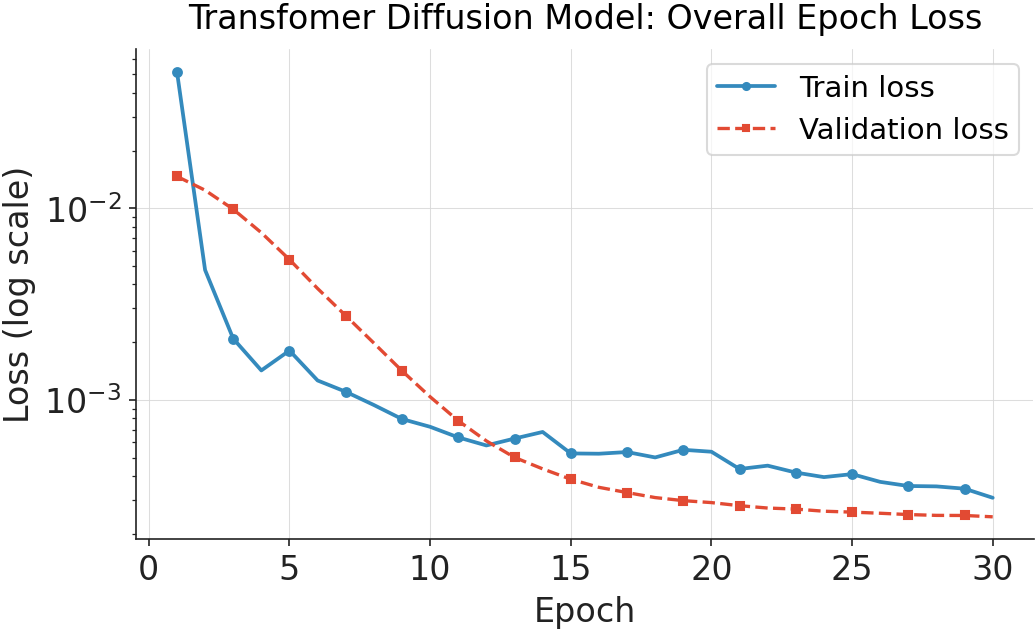

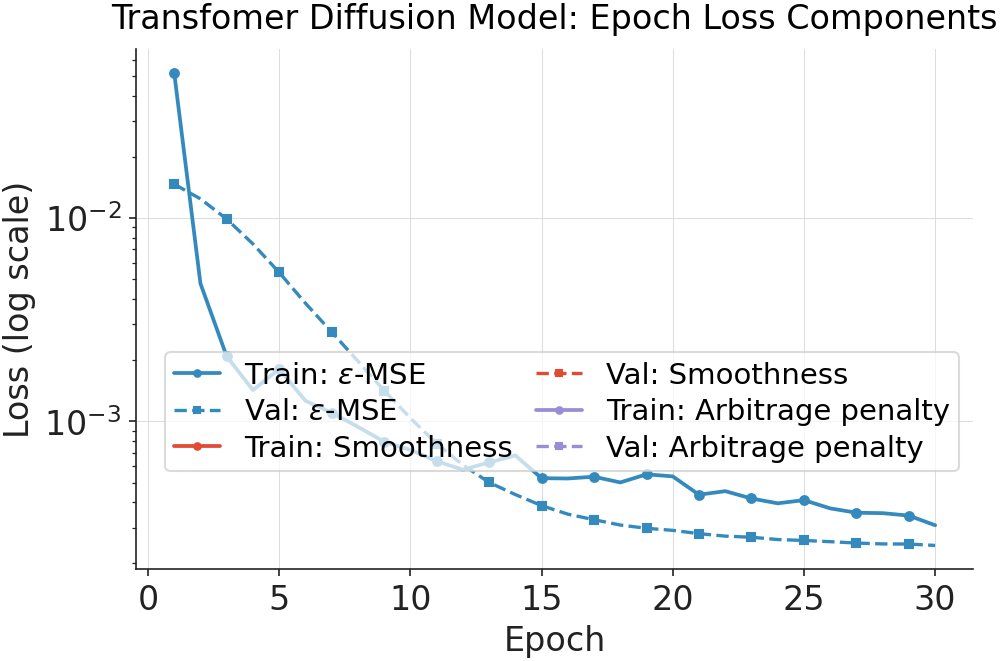

In [4]:
saved_paths = [
    plot_epoch_overall_loss(epoch_df, model_slug="unet", model_name="UNet"),
    plot_epoch_loss_components(epoch_df, model_slug="unet", model_name="UNet"),
]